## PREPARE - Loading My Data 📂


In [1]:
# Import pandas
import pandas as pd

In [2]:
# import the libraries we need
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
# Load the loan export data
# We're using Table 1 which contains loan exports by area
loan = pd.read_excel('loanExport.xlsx',
                           sheet_name='Loans',
                           header=0)  # The actual headers start at row 1

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [4]:
# Quick exploration
print("First 5 rows:")
loan.head()

First 5 rows:


,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description
0,BELABO-NGAOUNDERE RAILWAY RENEWAL CAMEROON,"Africa, Caribbean, Pacific countries + OCT",Cameroon,Transport,31/12/2021,"€17,100,000",The project consists of renewal of a section o...
1,BELABO-NGAOUNDERE RAILWAY RENEWAL CAMEROON,"Africa, Caribbean, Pacific countries + OCT",Cameroon,Transport,31/12/2021,"€106,000,000",The project consists of renewal of a section o...
2,JORDAN LOAN FOR SME RESILIENCE FACILITY,Mediterranean countries,Palestine*,Credit lines,30/12/2021,"€19,410,623",Long term financing for SMEs and Mid-Caps to i...
3,DSB NEW TRAINS,European Union,Denmark,Transport,22/12/2022,"€350,000,000",The project concerns the acquisition of 100 el...
4,MATERIEL ROULANT REGION HAUTS DE FRANCE,European Union,France,Transport,29/12/2021,"€282,000,000",Le projet consiste en l'acquisition de 33 rame...


In [5]:
loan.tail()

,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description
24517,CM 001 MERCURE,European Union,Italy,Energy,21/04/1959,"€9,000,000",Mise en exploitation du gisement de lignite de...
24518,CM 001 SINCAT,European Union,Italy,Industry,21/04/1959,"€7,000,000",Construction à Priolo (Sicile) d'une usine de ...
24519,CM 001 CELENE,European Union,Italy,Industry,21/04/1959,"€4,000,000",Construction à Priolo (Sicilie) d'une usine de...
24520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24521,Total,NaN,NaN,NaN,NaN,"€1,435,627,106,904",NaN


## PROCESS - Data Cleaning 🧹
#### Let's make this data easier to work with

**Note about the data structure:**  
Each row represents an individual loan.

In [6]:
# Check for missing values
print("Missing values per column:")
loan.isnull().sum()

Missing values per column:


,0
Name,1
Region,2
Country or Territory,2
Sector,2
Signature Date,2
Signed Amount,1
Description,2179


In [7]:
# Check for missing values
loan.isnull().sum().sum()

np.int64(2189)

In [8]:
loan = loan.iloc[:-2]

### Check for Duplicate Rows

**Hint:** Use `.duplicated().sum()` to count duplicate rows

In [9]:
# Check if any duplicates exist using the any() function (https://www.w3schools.com/python/ref_func_any.asp)
print(f"Any duplicates? {loan.duplicated().any()}")

# Count total duplicates
print(f"Number of duplicate rows: {loan.duplicated().sum()}")

Any duplicates? True
Number of duplicate rows: 1710


In [10]:
# View the duplicate rows
loan[loan.duplicated(keep=False)]  # keep=False shows ALL copies of the duplicates

,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description
71,ENDESA WIND AND SOLAR GREEN FRAMEWORK LOAN,European Union,Spain,Energy,28/06/2023,"€250,000,000",The operation is a framework loan to finance t...
80,STARSHIP (EGFF),European Union,Estonia,Services,20/12/2021,"€25,000,000","Starship Technologies, founded in Estonia, dev..."
81,STARSHIP (EGFF),European Union,Estonia,Services,20/12/2021,"€25,000,000","Starship Technologies, founded in Estonia, dev..."
130,UKRAINE DCFTA SUPPORT FACILITY,"Eastern Europe, Southern Caucasus",Ukraine,Credit lines,17/12/2021,"€20,000,000",Loan dedicated to finance eligible trade trans...
280,EAST AFRICA COVID-19 RAPID RESPONSE FACILITY,"Africa, Caribbean, Pacific countries + OCT",Regional - East Africa,Credit lines,24/11/2021,"€15,000,000",The East Africa COVID-19 Rapid Response Facili...
...,...,...,...,...,...,...,...
22365,OTE TELEPHONES REGIONAUX III,European Union,Greece,Telecom,25/06/1984,"€18,877,945",NaN
22529,DONG GASLINE 3,European Union,Denmark,Energy,09/06/1983,"€43,334,958",NaN
22530,DONG GASLINE 3,European Union,Denmark,Energy,09/06/1983,"€43,334,958",NaN
22986,TONGA DEVELOPMENT BANK - TDB,"Africa, Caribbean, Pacific countries + OCT",Tonga,Credit lines,01/10/1981,"€500,000",NaN


In [11]:
# Remove duplicates (keeps first occurrence)
loan = loan.drop_duplicates()

print(f"Duplicates removed!")
print(f"Rows remaining: {len(loan)}")

Duplicates removed!
Rows remaining: 22810


## ANALYSE - Basic Statistics 🧮
#### Let's understand my loan data

In [12]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22810 entries, 0 to 24519
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Name                  22810 non-null  object
 1   Region                22810 non-null  object
 2   Country or Territory  22810 non-null  object
 3   Sector                22810 non-null  object
 4   Signature Date        22810 non-null  object
 5   Signed Amount         22810 non-null  object
 6   Description           20671 non-null  object
dtypes: object(7)
memory usage: 1.4+ MB


In [13]:
# Descriptive statistics for loan only
loan.describe()

,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description
count,22810,22810,22810,22810,22810,22810,20671
unique,13704,9,189,13,6651,11761,11152
top,UPPER SILESIA URBAN FRAMEWORK PROGRAMME,European Union,Italy,Credit lines,23/07/2021,"€100,000,000",Financement d'investissements de petite ou moy...
freq,65,17642,4614,6291,67,766,288


### Summary Statistics for Categorical Columns

**NEW** Add `include='object'` to describe categorical data

In [14]:
# Get summary of categorical columns
loan.describe(include='object')

,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description
count,22810,22810,22810,22810,22810,22810,20671
unique,13704,9,189,13,6651,11761,11152
top,UPPER SILESIA URBAN FRAMEWORK PROGRAMME,European Union,Italy,Credit lines,23/07/2021,"€100,000,000",Financement d'investissements de petite ou moy...
freq,65,17642,4614,6291,67,766,288


### Value Counts for Key Categorical Variables

**Hint:** `.value_counts()` shows the frequency of each unique value

In [15]:
print("As percentages:")
(loan['Region'].value_counts(normalize=True) * 100).round(1)

As percentages:


,proportion
Region,
European Union,77.3
"Africa, Caribbean, Pacific countries + OCT",7.7
United Kingdom,5.9
Mediterranean countries,3.2
Enlargement Countries,2.8
Asia and Latin America,1.5
"Eastern Europe, Southern Caucasus",1.0
EFTA countries,0.3
South Africa,0.2


In [16]:
loan['Signed Amount'] = (
    loan['Signed Amount']
        .astype(str)
        .str.replace('€', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
)


In [17]:
top_loans = loan.nlargest(3, 'Signed Amount')
print("Top 3 loans by total signed amount:")
top_loans


Top 3 loans by total signed amount:


,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description
5867,NATIONAL GRID NETWORKS UPGRADE,United Kingdom,United Kingdom,Energy,05/11/2014,1.912655e+09,An investment programme consisting of several ...
5154,CDC COLLECTIVITES LOCALES MBIL,European Union,France,Credit lines,29/10/2015,1.802397e+09,Prêt intermédié multi-bénéficiaires pour le fi...
5404,URBAN MOBILITY FOR LONDON,United Kingdom,United Kingdom,Transport,19/06/2015,1.401738e+09,The project consists of schemes that renew and...


---
## Basic Grouping and Aggregation 🧮

`.groupby()` allows me to split data into groups and calculate statistics for each group - like GROUP BY in SQL!

## Groupby

In [18]:
groupby_region = loan.groupby('Region')['Signed Amount'].sum()
groupby_region

,Signed Amount
Region,
"Africa, Caribbean, Pacific countries + OCT",2.092931e+10
Asia and Latin America,1.863184e+10
EFTA countries,4.690139e+09
"Eastern Europe, Southern Caucasus",1.010798e+10
Enlargement Countries,3.895084e+10
European Union,1.122169e+12
Mediterranean countries,3.406313e+10
South Africa,2.668765e+09
United Kingdom,1.100678e+11


### Multiple Aggregations at Once

Using the .agg() function, example syntax below, adapting this to my dataframe and column names!
```python
df.groupby('group_col')['value_col_1'].agg(['min', 'max', 'count'])
```

In [19]:
Region_stats = loan.groupby('Region')['Signed Amount'].agg([
    'count',  # How many entries for this Region
    'sum',    # Total Signed Amount
    'mean',   # Average Signed Amount per Region
    'min',    # Lowest Signed Amount Region
    'max'     # Highest Signed Amount Region
])

print("Multiple statistics by Region:")
Region_stats

Multiple statistics by Region:


,count,sum,mean,min,max
Region,,,,,
"Africa, Caribbean, Pacific countries + OCT",1762,2.092931e+10,1.187816e+07,756.0,2.500000e+08
Asia and Latin America,333,1.863184e+10,5.595148e+07,469953.0,4.333974e+08
EFTA countries,78,4.690139e+09,6.012999e+07,71340.0,3.000000e+08
"Eastern Europe, Southern Caucasus",220,1.010798e+10,4.594536e+07,32890.0,4.000000e+08
Enlargement Countries,636,3.895084e+10,6.124345e+07,110339.0,7.000000e+08
European Union,17642,1.122169e+12,6.360781e+07,0.0,1.802397e+09
Mediterranean countries,736,3.406313e+10,4.628143e+07,20000.0,8.000000e+08
South Africa,52,2.668765e+09,5.132240e+07,2280320.0,1.349639e+08
United Kingdom,1351,1.100678e+11,8.147138e+07,84358.0,1.912655e+09


In [20]:
loan_analysis = loan.groupby('Region').agg({
    'Signed Amount': ['sum', 'mean'],
    'Region': 'count'  # Count how many entries per Region
})

# Round for readability
loan_analysis = loan_analysis.round(0)
print("Complex aggregation - different stats for different columns:")
loan_analysis

Complex aggregation - different stats for different columns:


Signed Amount             Region
                                                     sum        mean  count
Region                                                                     
Africa, Caribbean, Pacific countries + OCT  2.092931e+10  11878156.0   1762
Asia and Latin America                      1.863184e+10  55951485.0    333
EFTA countries                              4.690139e+09  60129987.0     78
Eastern Europe, Southern Caucasus           1.010798e+10  45945364.0    220
Enlargement Countries                       3.895084e+10  61243452.0    636
European Union                              1.122169e+12  63607814.0  17642
Mediterranean countries                     3.406313e+10  46281426.0    736
South Africa                                2.668765e+09  51322395.0     52
United Kingdom                              1.100678e+11  81471376.0   1351

In [21]:
groupby_sector = loan.groupby('Sector')['Signed Amount'].sum()
groupby_sector

,Signed Amount
Sector,
"Agriculture, fisheries, forestry",8.005426e+09
Composite infrastructure,1.785639e+10
Credit lines,3.819034e+11
Education,4.205213e+10
Energy,1.967435e+11
Health,3.187357e+10
Industry,1.387578e+11
Services,4.975325e+10
Solid waste,7.584325e+09


In [22]:
Sector_stats = loan.groupby('Sector')['Signed Amount'].agg([
    'count',  # How many entries for this Sector
    'sum',    # Total Signed Amount
    'mean',   # Average Signed Amount per Sector
    'min',    # Lowest Signed Amount Sector
    'max'     # Highest Signed Amount Sector
])

print("Multiple statistics by Sector:")
Sector_stats

Multiple statistics by Sector:


,count,sum,mean,min,max
Sector,,,,,
"Agriculture, fisheries, forestry",199,8.005426e+09,4.022827e+07,32890.0,7.000000e+08
Composite infrastructure,336,1.785639e+10,5.314401e+07,93581.0,6.245186e+08
Credit lines,6291,3.819034e+11,6.070632e+07,0.0,1.802397e+09
Education,544,4.205213e+10,7.730170e+07,14086.0,1.255000e+09
Energy,3146,1.967435e+11,6.253766e+07,2.0,1.912655e+09
Health,450,3.187357e+10,7.083015e+07,3000.0,1.000000e+09
Industry,3405,1.387578e+11,4.075118e+07,2473.0,8.000000e+08
Services,1267,4.975325e+10,3.926855e+07,0.0,1.200000e+09
Solid waste,315,7.584325e+09,2.407722e+07,97224.0,2.332177e+08


In [23]:
loan_analysis = loan.groupby('Sector').agg({
    'Signed Amount': ['sum', 'mean'],
    'Sector': 'count'  # Count how many entries per Sector
})

# Round for readability
loan_analysis = loan_analysis.round(0)
print("Complex aggregation - different stats for different columns:")
loan_analysis

Complex aggregation - different stats for different columns:


Signed Amount             Sector
                                           sum        mean  count
Sector                                                           
Agriculture, fisheries, forestry  8.005426e+09  40228270.0    199
Composite infrastructure          1.785639e+10  53144007.0    336
Credit lines                      3.819034e+11  60706318.0   6291
Education                         4.205213e+10  77301701.0    544
Energy                            1.967435e+11  62537656.0   3146
Health                            3.187357e+10  70830148.0    450
Industry                          1.387578e+11  40751185.0   3405
Services                          4.975325e+10  39268551.0   1267
Solid waste                       7.584325e+09  24077221.0    315
Telecom                           7.054326e+10  86983054.0    811
Transport                         2.990293e+11  80211709.0   3728
Urban development                 4.679671e+10  63410180.0    738
Water, sewerage                   7.137989e+10  45177144.0   1580

---
## Region and Sector Analysis 🔬

In [24]:
loan['Signed Amount'].describe()

,Signed Amount
count,2.281000e+04
mean,5.972288e+07
std,9.403847e+07
min,0.000000e+00
25%,8.401755e+06
50%,2.550000e+07
75%,7.000000e+07
max,1.912655e+09


In [25]:
# Signed Amount by grouped by Region
loan.groupby('Region')['Signed Amount'].describe() #I already looked at some of this data with .agg()

,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
"Africa, Caribbean, Pacific countries + OCT",1762.0,1.187816e+07,2.112495e+07,756.0,1761207.0,4877671.0,1.280884e+07,2.500000e+08
Asia and Latin America,333.0,5.595148e+07,6.616077e+07,469953.0,11611890.0,38000000.0,7.000000e+07,4.333974e+08
EFTA countries,78.0,6.012999e+07,6.863927e+07,71340.0,18400000.0,31032892.5,7.925000e+07,3.000000e+08
"Eastern Europe, Southern Caucasus",220.0,4.594536e+07,7.048539e+07,32890.0,6000000.0,20000000.0,5.015994e+07,4.000000e+08
Enlargement Countries,636.0,6.124345e+07,7.671724e+07,110339.0,10070500.0,33147596.0,9.000000e+07,7.000000e+08
European Union,17642.0,6.360781e+07,9.617503e+07,0.0,10000000.0,29154731.0,7.500000e+07,1.802397e+09
Mediterranean countries,736.0,4.628143e+07,7.483559e+07,20000.0,5523414.5,20000000.0,5.349672e+07,8.000000e+08
South Africa,52.0,5.132240e+07,2.823017e+07,2280320.0,30000000.0,48651700.0,6.000000e+07,1.349639e+08
United Kingdom,1351.0,8.147138e+07,1.271482e+08,84358.0,10356191.0,34913287.0,1.021807e+08,1.912655e+09


In [26]:
# Signed Amount by grouped by Sector
loan.groupby('Sector')['Signed Amount'].describe() #I already looked at some of this data with .agg()

,count,mean,std,min,25%,50%,75%,max
Sector,,,,,,,,
"Agriculture, fisheries, forestry",199.0,4.022827e+07,8.731560e+07,32890.0,3393406.50,8201867.0,3.283840e+07,7.000000e+08
Composite infrastructure,336.0,5.314401e+07,8.696315e+07,93581.0,8000000.00,20823783.0,5.306745e+07,6.245186e+08
Credit lines,6291.0,6.070632e+07,8.958168e+07,0.0,9991421.50,29277562.0,7.500000e+07,1.802397e+09
Education,544.0,7.730170e+07,1.034064e+08,14086.0,17500000.00,49494830.0,9.928072e+07,1.255000e+09
Energy,3146.0,6.253766e+07,9.316193e+07,2.0,11500000.00,29090652.5,7.500000e+07,1.912655e+09
Health,450.0,7.083015e+07,8.928123e+07,3000.0,15947500.00,45537132.0,1.000000e+08,1.000000e+09
Industry,3405.0,4.075118e+07,7.398947e+07,2473.0,4240000.00,12962435.0,4.345842e+07,8.000000e+08
Services,1267.0,3.926855e+07,8.725572e+07,0.0,2438924.50,9800000.0,2.925000e+07,1.200000e+09
Solid waste,315.0,2.407722e+07,3.477271e+07,97224.0,5178152.00,11400000.0,2.676342e+07,2.332177e+08


### Analysis

**NEW!** Use `pd.crosstab()` to create a cross-tabulation between two categorical variables. I mainly used this function for frequency counts.

In [27]:
# Cross-tabulation of sector and region
sector_region = pd.crosstab(loan['Sector'], loan['Region'])
sector_region

Region,"Africa, Caribbean, Pacific countries + OCT",Asia and Latin America,EFTA countries,"Eastern Europe, Southern Caucasus",Enlargement Countries,European Union,Mediterranean countries,South Africa,United Kingdom
Sector,,,,,,,,,
"Agriculture, fisheries, forestry",35,22,0,14,5,112,11,0,0
Composite infrastructure,1,1,0,3,3,237,3,2,86
Credit lines,480,37,6,59,226,5126,201,23,133
Education,3,2,0,3,7,460,8,0,61
Energy,267,103,37,34,72,2270,118,10,235
Health,13,3,0,0,9,391,6,0,28
Industry,319,39,7,12,68,2652,79,3,226
Services,339,12,2,7,27,760,89,1,30
Solid waste,7,8,1,5,3,275,3,0,13


In [28]:
# Show as percentages using normalize parameter, note the american spelling!
(pd.crosstab(loan['Sector'], loan['Region'], normalize='index') * 100).round(2)

Region,"Africa, Caribbean, Pacific countries + OCT",Asia and Latin America,EFTA countries,"Eastern Europe, Southern Caucasus",Enlargement Countries,European Union,Mediterranean countries,South Africa,United Kingdom
Sector,,,,,,,,,
"Agriculture, fisheries, forestry",17.59,11.06,0.00,7.04,2.51,56.28,5.53,0.00,0.00
Composite infrastructure,0.30,0.30,0.00,0.89,0.89,70.54,0.89,0.60,25.60
Credit lines,7.63,0.59,0.10,0.94,3.59,81.48,3.20,0.37,2.11
Education,0.55,0.37,0.00,0.55,1.29,84.56,1.47,0.00,11.21
Energy,8.49,3.27,1.18,1.08,2.29,72.16,3.75,0.32,7.47
Health,2.89,0.67,0.00,0.00,2.00,86.89,1.33,0.00,6.22
Industry,9.37,1.15,0.21,0.35,2.00,77.89,2.32,0.09,6.64
Services,26.76,0.95,0.16,0.55,2.13,59.98,7.02,0.08,2.37
Solid waste,2.22,2.54,0.32,1.59,0.95,87.30,0.95,0.00,4.13


---
## Creating New Columns 🆕

I can create new columns from existing data to gain additional insights!

An example is to create Signed Amount groups from Signed Amount data.

### Create Signed Amount Groups

**Hint:** Using `pd.cut()` to bin continuous data into categories. [Check out geeks for geeks for more](https://www.geeksforgeeks.org/python/pandas-cut-method-in-python/).

In [29]:
loan['Signed Amount Group'] = pd.cut(loan['Signed Amount'],
                        bins=[0, 8500000, 25500000, 70000000, 2000000000],
                        labels=['0.00-8.5M', '8.6-25.5M', '25.6-70.0M', '70.1M-2000.0M'])

In [30]:
loan[['Signed Amount', 'Signed Amount Group']]

,Signed Amount,Signed Amount Group
0,17100000.0,8.6-25.5M
1,106000000.0,70.1M-2000.0M
2,19410623.0,8.6-25.5M
3,350000000.0,70.1M-2000.0M
4,282000000.0,70.1M-2000.0M
...,...,...
24515,4000000.0,0.00-8.5M
24516,10127485.0,8.6-25.5M
24517,9000000.0,8.6-25.5M
24518,7000000.0,0.00-8.5M


In [31]:
# Create Signed Amount groups
loan['Signed Amount Group'] = pd.cut(loan['Signed Amount'],
                        bins=[0, 8500000, 25500000, 70000000, 2000000000],
                        labels=['0.00-8.5M', '8.6-25.5M', '25.6-70.0M', '70.1M-2000.0M'])

print("Signed Amount groups created!")
print("\nSigned Amount group distribution:")
print(loan['Signed Amount Group'].value_counts().sort_index())

Signed Amount groups created!

Signed Amount group distribution:
Signed Amount Group
0.00-8.5M        5734
8.6-25.5M        5675
25.6-70.0M       5757
70.1M-2000.0M    5642
Name: count, dtype: int64


### Create Binary Column

**Hint:** Using `.map()` or simple comparison operators to create binary columns. [See geeks for geeks for more help.](https://www.geeksforgeeks.org/python/python-pandas-map/)

In [32]:
# Convert Region to binary (1 for Yes, 0 for No)
loan['Region Binary'] = loan['Region'].map({'European Union': 1}).fillna(0).astype(int)

print(loan[['Region', 'Region Binary']].head())


                                       Region  Region Binary
0  Africa, Caribbean, Pacific countries + OCT              0
1  Africa, Caribbean, Pacific countries + OCT              0
2                     Mediterranean countries              0
3                              European Union              1
4                              European Union              1


In [33]:
# Convert Region to binary (1 for Yes, 0 for No)
#→ produces True/False
loan['Region Binary 2'] = (loan['Region'] == 'European Union').astype(int)

print("Binary Region column 2 created!")
print(loan[['Region', 'Region Binary 2']].head())

Binary Region column 2 created!
                                       Region  Region Binary 2
0  Africa, Caribbean, Pacific countries + OCT                0
1  Africa, Caribbean, Pacific countries + OCT                0
2                     Mediterranean countries                0
3                              European Union                1
4                              European Union                1


In [34]:
# Create a column for high signed amounts (above median signed amount)
median_signed_amount = loan['Signed Amount'].median()
loan['High Signed Amount'] = loan['Signed Amount'] > median_signed_amount

print(f"Median Signed Amount: €{median_signed_amount:,.2f}")
print("\nHigh signed amount distribution:")
print(loan['High Signed Amount'].value_counts())

Median Signed Amount: €25,500,000.00

High signed amount distribution:
High Signed Amount
False    11411
True     11399
Name: count, dtype: int64


## Basic Data Viz with Pandas 📊/Data Visualisation with Pandas Only!

Pandas has built-in plotting using `.plot()` - no need for data visualisation libraries yet!

Remember I don't need this to look pretty, I just want to use this to aid my understanding of the data

### Bar Charts

**Hint:** Use `.plot(kind='bar')` or `.plot.bar()` to create bar charts

<Axes: title={'center': 'Region Distribution'}, xlabel='Region Binary'>

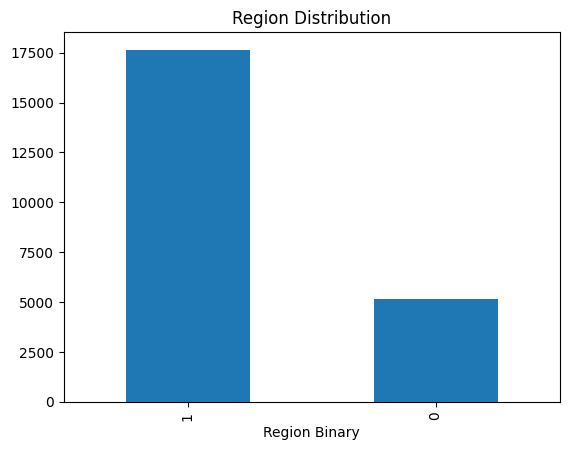

In [35]:
# Bar chart of region counts
loan['Region Binary'].value_counts().plot(kind='bar', title='Region Distribution')

<Axes: title={'center': 'Count by Region'}, xlabel='Region', ylabel='Count'>

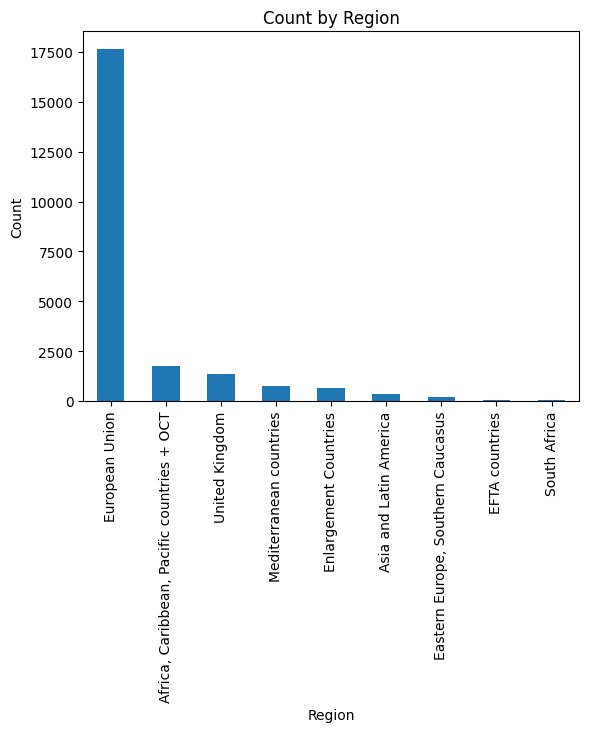

In [36]:
# Note that so far I have used .plot(kind='bar') but I can also use .plot.bar() too
# Bar chart of region distribution
loan['Region'].value_counts().plot.bar(title='Count by Region',
                                         xlabel='Region',
                                         ylabel='Count')

In [37]:
top_5_loans = loan.nlargest(5, 'Signed Amount')
top_5_loans

,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description,Signed Amount Group,Region Binary,Region Binary 2,High Signed Amount
5867,NATIONAL GRID NETWORKS UPGRADE,United Kingdom,United Kingdom,Energy,05/11/2014,1.912655e+09,An investment programme consisting of several ...,70.1M-2000.0M,0,0,True
5154,CDC COLLECTIVITES LOCALES MBIL,European Union,France,Credit lines,29/10/2015,1.802397e+09,Prêt intermédié multi-bénéficiaires pour le fi...,70.1M-2000.0M,1,1,True
5404,URBAN MOBILITY FOR LONDON,United Kingdom,United Kingdom,Transport,19/06/2015,1.401738e+09,The project consists of schemes that renew and...,70.1M-2000.0M,0,0,True
1992,SCHOOL UPGRADE INVESTMENT PLAN FRAMEWORK LOAN II,European Union,Italy,Education,29/07/2019,1.255000e+09,The Project supports the second phase of the N...,70.1M-2000.0M,1,1,True
2416,STRATEGIC RESEARCH AND INNOVATION SPAIN,European Union,Spain,Services,19/12/2018,1.200000e+09,"Financing of the Research, Development and Inn...",70.1M-2000.0M,1,1,True


<Axes: ylabel='Name'>

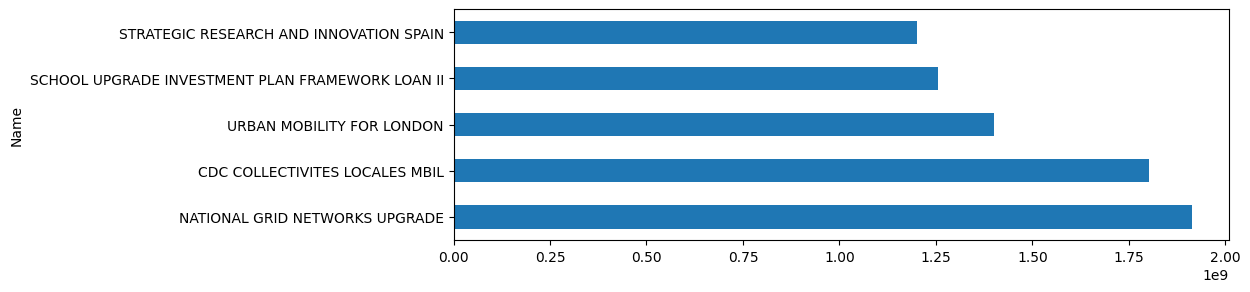

In [38]:
# Simple bar chart
# set the index to be loan name - i.e. use this as my x-axis
top_5_loans.set_index('Name')['Signed Amount'].plot(kind='barh', figsize=(10, 3))

<Axes: title={'center': 'Top Signed Amount by Sector'}, xlabel='Signed Amount', ylabel='Sector'>

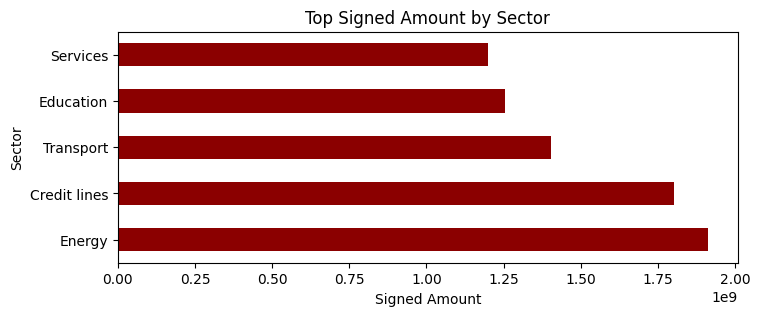

In [39]:
# Horizontal bar chart - better for long names
top_5_loans.set_index('Sector')['Signed Amount'].plot(kind='barh',
                                                                       figsize=(8, 3),
                                                                       title='Top Signed Amount by Sector',
                                                                       xlabel='Signed Amount',
                                                                       color='darkred')

### Histograms

**Hint:** Use `.plot(kind='hist')` or `.plot.hist()` to show distribution of numerical data

<Axes: title={'center': 'Signed Amount Distribution'}, xlabel='Signed Amount', ylabel='Frequency'>

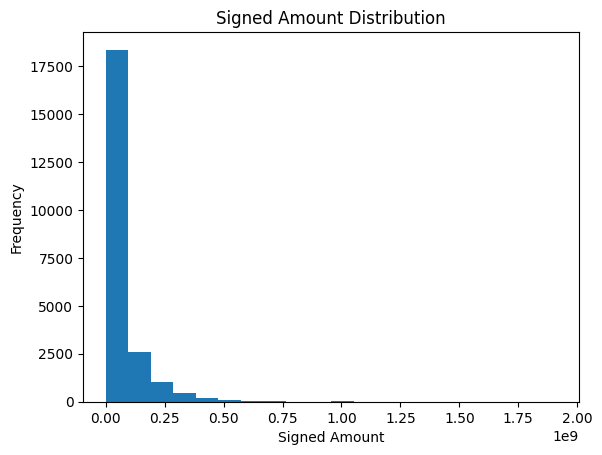

In [40]:
# EXAMPLE: Histogram of signed amount distribution
loan['Signed Amount'].plot.hist(bins=20, title='Signed Amount Distribution', xlabel='Signed Amount', ylabel='Frequency')

,Signed Amount
Region Binary,
0,"Axes(0.125,0.11;0.775x0.77)"
1,"Axes(0.125,0.11;0.775x0.77)"


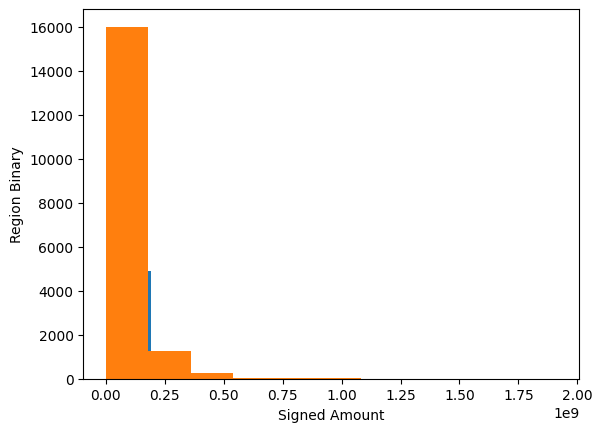

In [41]:
loan.groupby('Region Binary')['Signed Amount'].plot.hist(bins=10, xlabel='Signed Amount', ylabel='Region Binary')

### Pie Charts

**Hint:** Use `.plot.pie()` to show proportions

<Axes: title={'center': 'Region Binary'}>

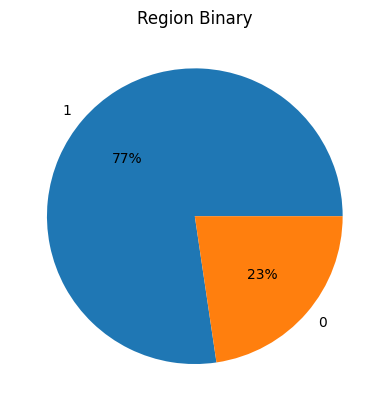

In [42]:
# EXAMPLE: Pie chart of Region Binary
loan['Region Binary'].value_counts().plot.pie( autopct='%1.0f%%',
                                        title='Region Binary',
                                        ylabel='')

# note by default, pandas doesn't show percentage labels.
# we use use autopct='%1.0f%%'to show these values to 0dp

<Axes: title={'center': 'Sector Distribution'}>

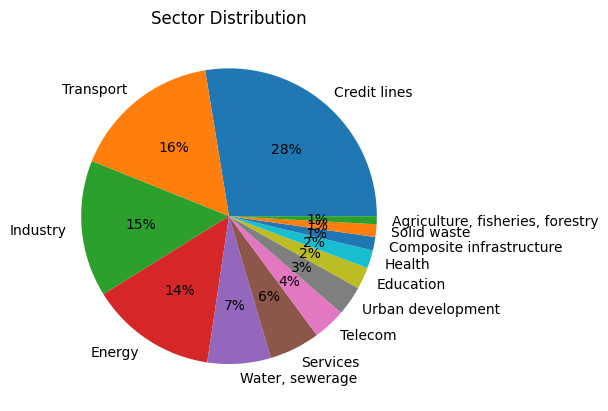

In [43]:
# Create a pie chart of sector distribution, show the percentages to 1dp, give it an appropriate title
loan['Sector'].value_counts().plot.pie(autopct='%1.0f%%',
                                     title='Sector Distribution',
                                     ylabel='')

### Line Plots for Trends

**Hint:** Line plots work well for showing trends over time or continuous variables

In [44]:
avg_by_date = loan.groupby('Signature Date')['Signed Amount'].mean()

In [45]:
avg_by_date = avg_by_date.sort_index()
avg_by_date.tail()

,Signed Amount
Signature Date,
31/12/1991,6000000.0
31/12/1997,156129660.0
31/12/2002,18491200.0
31/12/2013,100000000.0
31/12/2021,61550000.0


In [46]:
# Ensure Signature Date is datetime
loan['Signature Date'] = pd.to_datetime(loan['Signature Date'], errors='coerce')

/tmp/ipython-input-1308285578.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  loan['Signature Date'] = pd.to_datetime(loan['Signature Date'], errors='coerce')


In [47]:
loan = loan[loan['Signature Date'].dt.year >= 2024]

<Axes: title={'center': 'Average Signed Amount by Signature Date'}, xlabel='Signature Date', ylabel='Average Signed Amount'>

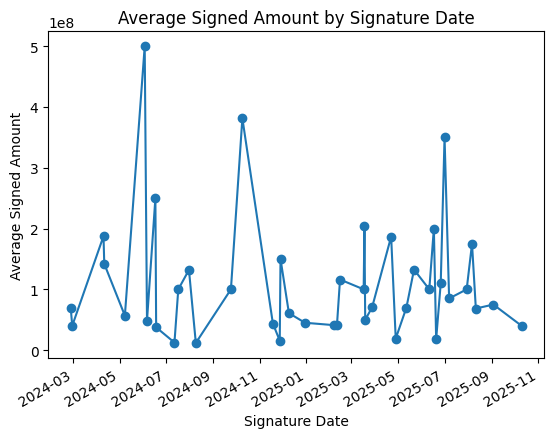

In [48]:
# Average signed amount by signature Date
loan.groupby('Signature Date')['Signed Amount'].mean().plot(title='Average Signed Amount by Signature Date',
                                                           xlabel='Signature Date',
                                                           ylabel='Average Signed Amount',
                                                           marker='o')

In [49]:
avg_by_date = loan.groupby('Signature Date')['Signed Amount'].mean()
avg_by_date.head()

,Signed Amount
Signature Date,
2024-02-27,70000000.0
2024-02-29,40000000.0
2024-04-10,187500000.0
2024-04-11,142000000.0
2024-05-08,56749875.0


### Grouped Bar Charts

**Hint:** I can plot grouped data directly from a crosstab or groupby result

<Axes: title={'center': 'Region Binary by Sector'}, xlabel='Sector', ylabel='Region Binary'>

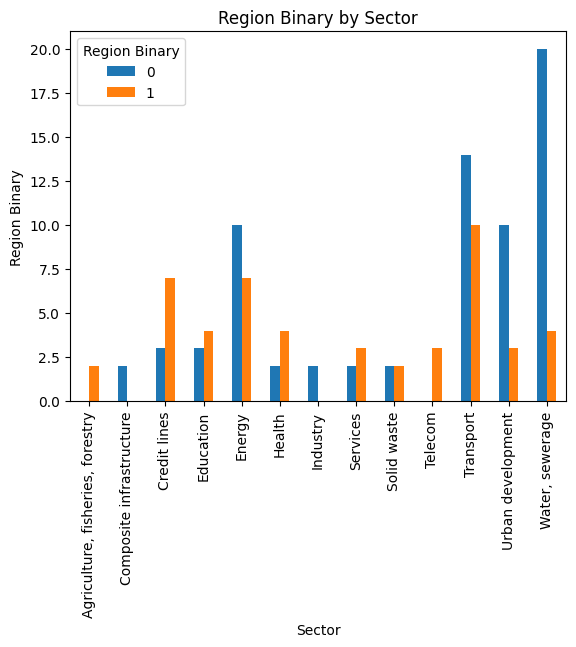

In [50]:
# Example - Region Binary by Sector
pd.crosstab(loan['Sector'], loan['Region Binary']).plot.bar(title='Region Binary by Sector',
                                                         xlabel='Sector',
                                                         ylabel='Region Binary')

In [51]:
pd.crosstab(loan['Sector'], loan['Region Binary'])

Region Binary,0,1
Sector,,
"Agriculture, fisheries, forestry",0,2
Composite infrastructure,2,0
Credit lines,3,7
Education,3,4
Energy,10,7
Health,2,4
Industry,2,0
Services,2,3
Solid waste,2,2


<Axes: title={'center': 'Region Binary by Signed Amount Group'}, xlabel='Signed Amount Group', ylabel='Region Binary'>

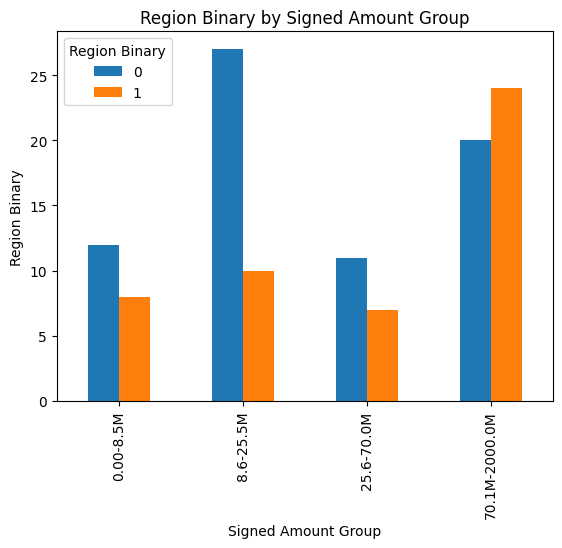

In [52]:
# Example - Region Binary by signed amount group
pd.crosstab(loan['Signed Amount Group'], loan['Region Binary']).plot.bar(title='Region Binary by Signed Amount Group',
                                                         xlabel='Signed Amount Group',
                                                         ylabel='Region Binary')

### Grouped Bar Charts

**Hint:** I can plot grouped data directly from a crosstab or groupby result

In [53]:
# How many names have MORE than 100,000,000 Signed Amount

high_signed_amount_name = loan[loan['Signed Amount'] > 100000000] #apply a mask to filter and only show regions with >1B signed amount
high_signed_amount_name.head() # quick check of my new df

,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description,Signed Amount Group,Region Binary,Region Binary 2,High Signed Amount
90,PEKAO LEASING LOAN FOR SMES AND MID-CAPS V,European Union,Poland,Credit lines,2024-07-31,132000000.0,The operation is aimed at supporting the finan...,70.1M-2000.0M,1,1,True
192,PKP INTERCITY FLEET RENEWAL AND EXPANSION,European Union,Poland,Transport,2025-03-18,203621758.0,The project consists of acquisition of new ele...,70.1M-2000.0M,1,1,True
455,ELECTRICA DISTRIBUTION NETWORK UPGRADE,European Union,Romania,Energy,2024-05-08,120000000.0,The investment programme comprises a large num...,70.1M-2000.0M,1,1,True
456,FIBRE OPTIC NETWORK EXPANSION POLAND (FONEXP),European Union,Poland,Telecom,2025-06-26,109995259.0,The project relates to the deployment of a new...,70.1M-2000.0M,1,1,True
603,PUNE METRO RAIL PROJECT,Asia and Latin America,India,Transport,2025-08-06,150000000.0,Construction of two metro lines totalling of 3...,70.1M-2000.0M,0,0,True


In [54]:
# to count the number of names, I can use .shape[0]
high_signed_amount_name.shape[0] #remember 0 is our rows axis

25

In [55]:
# to count the number of names, I could also use len()
len(high_signed_amount_name)

25

### Filtering and Sorting
**Skills: Boolean indexing, .query(), .nlargest(), .nsmallest() (Session 16)**

In [56]:
# Filter to show only European Union regions (not United Kingdom)
# Display Name, and Signed Amount columns

# MY CODE:
# Boolean mask for rows *starting with* 'European Union'
mask_united_kingdom = loan['Region'].astype(str).str.startswith('European')
# Create the version for regions
loan_eu_areas = loan[mask_united_kingdom]
loan_eu_areas.head() # check it's worked!

,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description,Signed Amount Group,Region Binary,Region Binary 2,High Signed Amount
90,PEKAO LEASING LOAN FOR SMES AND MID-CAPS V,European Union,Poland,Credit lines,2024-07-31,132000000.0,The operation is aimed at supporting the finan...,70.1M-2000.0M,1,1,True
192,PKP INTERCITY FLEET RENEWAL AND EXPANSION,European Union,Poland,Transport,2025-03-18,203621758.0,The project consists of acquisition of new ele...,70.1M-2000.0M,1,1,True
204,GEFA LOAN FOR SMES AND MIDCAPS IV,European Union,Germany,Credit lines,2024-02-29,40000000.0,Financing of small and medium scale projects u...,25.6-70.0M,1,1,True
216,ELECTRICA DISTRIBUTION NETWORK UPGRADE,European Union,Romania,Energy,2024-05-08,90000000.0,The investment programme comprises a large num...,70.1M-2000.0M,1,1,True
328,BOS BANK LOAN FOR SME MIDCAPS AND CLIMATE ACTION,European Union,Poland,Credit lines,2025-09-03,75000000.0,Intermediate finance support for small and med...,70.1M-2000.0M,1,1,True


In [57]:
# The 5 names with the LOWEST signed amount
# Show name and signed amount columns

# MY CODE:
loan.nsmallest(5, 'Signed Amount')[['Name', 'Signed Amount']]

,Name,Signed Amount
6515,MONTENEGRO WATER AND SANITATION,392000.0
4613,EU FUNDS CASTILLA Y LEON CO-FINANCING 2014-20,520000.0
537,EU FUNDS CASTILLA Y LEON CO-FINANCING 2014-20,600000.0
307,UKRAINE PUBLIC BUILDINGS ENERGY EFFICIENCY,1000000.0
8200,MONTENEGRO WATER AND SANITATION,1707542.0


In [58]:
# Filter to show areas where signed amount is greater than 100,000,000
# AND region is European Union
# Display name, region, and signed amount columns

# MY CODE:
onehundredM_european_union_mask = ((loan['Signed Amount'] > 100000000) & (loan['Region'].astype(str).str.startswith('European')))

filtered = loan[onehundredM_european_union_mask] # filter the df using my mask
filtered[['Name', 'Region', 'Signed Amount']] # 'double' brackets here because I need to put a list of column names in my square brackets

,Name,Region,Signed Amount
90,PEKAO LEASING LOAN FOR SMES AND MID-CAPS V,European Union,132000000.0
192,PKP INTERCITY FLEET RENEWAL AND EXPANSION,European Union,203621758.0
455,ELECTRICA DISTRIBUTION NETWORK UPGRADE,European Union,120000000.0
456,FIBRE OPTIC NETWORK EXPANSION POLAND (FONEXP),European Union,109995259.0
668,SUSTAINABLE URBAN DEVELOPMENT IN GREECE,European Union,200000000.0
683,FRENCH OFFSHORE ROUND 1 - COURSEULLES-SUR-MER,European Union,350000000.0
713,COVID19 DISASTER PREVENTION & CLIMATE ADAPTATION,European Union,320700000.0
715,AVE Y VASCA EXTENSION,European Union,400000000.0
1100,NEW SLUSSEN STOCKHOLM,European Union,381570161.0
1241,TRENITALIA ROLLING STOCK RENEWAL PROGRAM,European Union,150000000.0


### Creating New Columns
**Skills: Column creation and modification (Session 16)**

In [59]:
# TODO: Create a new column called 'amount_percentage' that shows
# what percentage of total is made up of region
# Formula: (signed_amount / total) * 100

# MY CODE HERE:

# note that I am creating a new column here, this percentage column didn't previously exist in my df
total_sum = Region_stats['sum'].sum()
Region_stats['amount_percentage'] = ((Region_stats['sum'] / total_sum) * 100).round(1)

# Verify it was created
print("amount_percentage column created!")
Region_stats

amount_percentage column created!


,count,sum,mean,min,max,amount_percentage
Region,,,,,,
"Africa, Caribbean, Pacific countries + OCT",1762,2.092931e+10,1.187816e+07,756.0,2.500000e+08,1.5
Asia and Latin America,333,1.863184e+10,5.595148e+07,469953.0,4.333974e+08,1.4
EFTA countries,78,4.690139e+09,6.012999e+07,71340.0,3.000000e+08,0.3
"Eastern Europe, Southern Caucasus",220,1.010798e+10,4.594536e+07,32890.0,4.000000e+08,0.7
Enlargement Countries,636,3.895084e+10,6.124345e+07,110339.0,7.000000e+08,2.9
European Union,17642,1.122169e+12,6.360781e+07,0.0,1.802397e+09,82.4
Mediterranean countries,736,3.406313e+10,4.628143e+07,20000.0,8.000000e+08,2.5
South Africa,52,2.668765e+09,5.132240e+07,2280320.0,1.349639e+08,0.2
United Kingdom,1351,1.100678e+11,8.147138e+07,84358.0,1.912655e+09,8.1


In [60]:
# TODO: Create a new column called 'amount_percentage' that shows
# what percentage of total is made up of sector
# Formula: (signed_amount / total) * 100

# YOUR CODE HERE:

# note that I am creating a new column here, this percentage column didn't previously exist in my df
total_sum = Sector_stats['sum'].sum()
Sector_stats['amount_percentage'] = ((Sector_stats['sum'] / total_sum) * 100).round(1)

# Verify it was created
print("amount_percentage column created!")
Sector_stats

amount_percentage column created!


,count,sum,mean,min,max,amount_percentage
Sector,,,,,,
"Agriculture, fisheries, forestry",199,8.005426e+09,4.022827e+07,32890.0,7.000000e+08,0.6
Composite infrastructure,336,1.785639e+10,5.314401e+07,93581.0,6.245186e+08,1.3
Credit lines,6291,3.819034e+11,6.070632e+07,0.0,1.802397e+09,28.0
Education,544,4.205213e+10,7.730170e+07,14086.0,1.255000e+09,3.1
Energy,3146,1.967435e+11,6.253766e+07,2.0,1.912655e+09,14.4
Health,450,3.187357e+10,7.083015e+07,3000.0,1.000000e+09,2.3
Industry,3405,1.387578e+11,4.075118e+07,2473.0,8.000000e+08,10.2
Services,1267,4.975325e+10,3.926855e+07,0.0,1.200000e+09,3.7
Solid waste,315,7.584325e+09,2.407722e+07,97224.0,2.332177e+08,0.6


In [61]:
# TODO: Identify the top 5 regions with the highest signed amount

# YOUR CODE HERE:
regional_stats = loan.groupby('Region')['Signed Amount'].sum().nlargest(5) # I don't actually need the groupby with this data..!
print("Total Signed Amount by region:")
regional_stats


Total Signed Amount by region:


,Signed Amount
Region,
European Union,5.182048e+09
"Eastern Europe, Southern Caucasus",1.597000e+09
Asia and Latin America,8.500000e+08
Enlargement Countries,8.460143e+08
Mediterranean countries,4.045944e+08


In [62]:
# TODO: Identify the top 5 names with unique regions with the highest signed amount

# YOUR CODE HERE:
top5_unique_regions = (loan.sort_values('Signed Amount', ascending=False).drop_duplicates(subset='Region', keep='first')
.head(5)[['Name', 'Region', 'Signed Amount']])

top5_unique_regions



,Name,Region,Signed Amount
3555,AVE Y VASCA EXTENSION,European Union,600000000.0
754,CORRIDOR VC MEDAKOVO - POPRIKUSE,Enlargement Countries,340000000.0
3834,GEORGIA TRANSPORT CONNECTIVITY,"Eastern Europe, Southern Caucasus",250000000.0
2003,PUNE METRO RAIL PROJECT,Asia and Latin America,200000000.0
8103,SOREK DESALINATION PLANT,Mediterranean countries,142000000.0


In [63]:
# TODO: Identify the top 5 sectors with the highest signed amount

# YOUR CODE HERE:
sector_stats = loan.groupby('Sector')['Signed Amount'].sum().nlargest(5) # I don't actually need the groupby with this data..!
print("Total Signed Amount by sector:")
sector_stats


Total Signed Amount by sector:


,Signed Amount
Sector,
Transport,4.206680e+09
Energy,1.094600e+09
"Water, sewerage",9.277957e+08
Urban development,8.886000e+08
Credit lines,5.738789e+08


In [64]:
# TODO: Identify the top 5 names with unique sectors with the highest signed amount

# YOUR CODE HERE:
top5_unique_sectors = (loan.sort_values('Signed Amount', ascending=False).drop_duplicates(subset='Sector', keep='first')
.head(5)[['Name', 'Sector', 'Signed Amount']])

top5_unique_sectors



,Name,Sector,Signed Amount
3555,AVE Y VASCA EXTENSION,Transport,600000000.0
683,FRENCH OFFSHORE ROUND 1 - COURSEULLES-SUR-MER,Energy,350000000.0
713,COVID19 DISASTER PREVENTION & CLIMATE ADAPTATION,Services,320700000.0
1105,UKRAINE PUBLIC BUILDINGS ENERGY EFFICIENCY,Urban development,200000000.0
8103,SOREK DESALINATION PLANT,"Water, sewerage",142000000.0


In [65]:
# TODO: Calculate the average (mean) Signed Amount across all regions
# Then identify which regions are above this average

# YOUR CODE HERE:
avg_signed_amount_region = groupby_region.mean()

regions_above_average = groupby_region[groupby_region > avg_signed_amount_region]

print(f"Average total Signed Amount by Region: {avg_signed_amount_region}")
print("\nRegions above average:")
regions_above_average


Average total Signed Amount by Region: 151364320945.8889

Regions above average:


,Signed Amount
Region,
European Union,1.122169e+12


In [66]:
# TODO: Calculate the average (mean) Signed Amount across all sectors
# Then identify which sectors are above this average

# YOUR CODE HERE:
avg_signed_amount_sector = groupby_sector.mean()

sectors_above_average = groupby_sector[groupby_sector > avg_signed_amount_sector]

print(f"Average total Signed Amount by Sector: {avg_signed_amount_sector}")
print("\nSectors above average:")
sectors_above_average


Average total Signed Amount by Sector: 104790683731.76923

Sectors above average:


,Signed Amount
Sector,
Credit lines,3.819034e+11
Energy,1.967435e+11
Industry,1.387578e+11
Transport,2.990293e+11


In [67]:
# TODO: Count how many regions have signed amount above 70B
# Use boolean filtering with .sum() or len()

# YOUR CODE HERE:
med_regions = groupby_region[groupby_region > 70000000000]
len(med_regions)

2

In [68]:
# TODO: Count how many sectors have signed amount above 50B
# Use boolean filtering with .sum() or len()

# YOUR CODE HERE:
med_sectors = groupby_sector[groupby_sector > 50000000000]
len(med_sectors)

6

<Axes: title={'center': 'Regions by Signed Amount'}, xlabel='Signed Amount', ylabel='Region'>

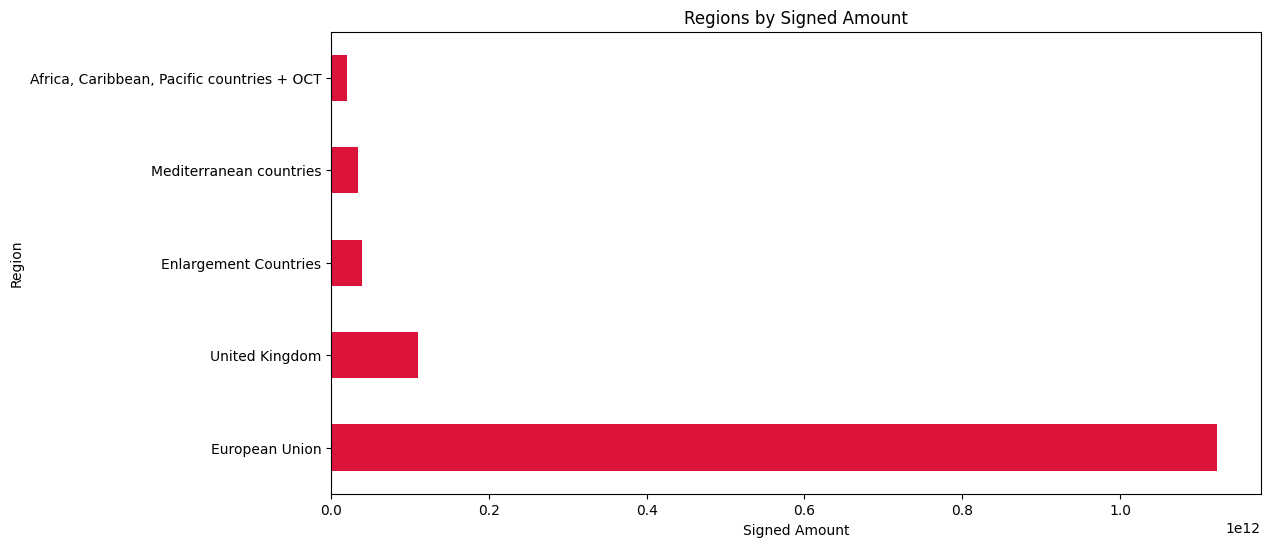

In [69]:
# TODO: Create a horizontal bar chart showing the regions by signed amount
# Include appropriate title, labels, and choose a color

# YOUR CODE HERE:
top_region = groupby_region.nlargest()
top_region.plot(kind='barh',
                  figsize=(12, 6),
                  title='Regions by Signed Amount',
                  xlabel='Signed Amount',
                  ylabel='Region',
                  color='crimson')


<Axes: title={'center': 'Top Sectors by Signed Amount'}, xlabel='Signed Amount', ylabel='Sector'>

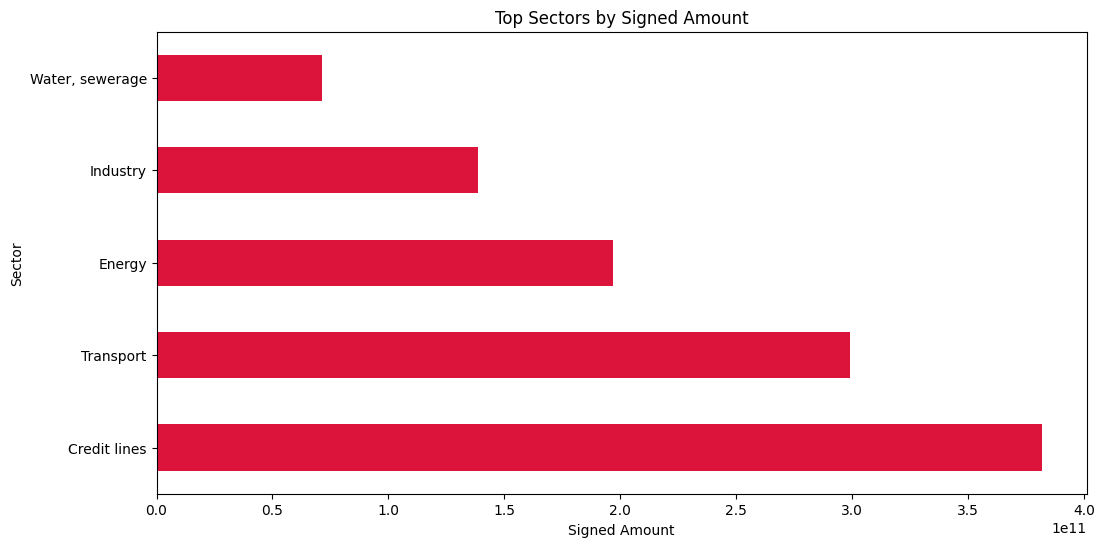

In [70]:
# TODO: Create a horizontal bar chart showing the sectors by signed amount
# Include appropriate title, labels, and choose a color

# YOUR CODE HERE:
top_sector = groupby_sector.nlargest()
top_sector.plot(kind='barh',
                  figsize=(12, 6),
                  title='Top Sectors by Signed Amount',
                  xlabel='Signed Amount',
                  ylabel='Sector',
                  color='crimson')


# 🤖 Introduction to Machine Learning** 🤖
## **Demo: Predicting Region Binary with Logistic Regression**

## Data Preparation

I need to:
1. Remove useless columns
2. Convert our target variable (`Attrition`) to numbers
3. Convert all text columns to numbers (or True/False) using **one-hot encoding**

### Drop Unnecessary Columns

In [71]:
loan.columns

Index(['Name', 'Region', 'Country or Territory', 'Sector', 'Signature Date',
       'Signed Amount', 'Description', 'Signed Amount Group', 'Region Binary',
       'Region Binary 2', 'High Signed Amount'],
      dtype='object')

In [72]:
# Drop columns that don't help predict anything
loan = loan.drop(['Name', 'Region', 'Country or Territory', 'Description', 'Signed Amount Group', 'Region Binary 2', 'High Signed Amount'], axis=1)

# Check the shape now
loan.shape

(119, 4)

<details>
<summary>💡 Why drop these columns?</summary>

- **EmployeeCount**: Always 1 (same for everyone)
- **Over18**: Always "Yes" (same for everyone)
- **StandardHours**: Always 80 (same for everyone)
- **EmployeeNumber**: Just an ID (doesn't predict behaviour)

Columns that are the same for everyone can't help predict differences in outcomes!
</details>

In [73]:
loan.head()

,Sector,Signature Date,Signed Amount,Region Binary
90,Credit lines,2024-07-31,132000000.0,1
155,"Water, sewerage",2025-03-28,70207900.0,0
186,Transport,2024-09-24,100000000.0,0
192,Transport,2025-03-18,203621758.0,1
204,Credit lines,2024-02-29,40000000.0,1


### Encode the Target Variable

### One-Hot Encoding for Categorical Variables

In [74]:
# Before encoding - check how many columns we have
print("Columns before encoding:", loan.shape[1])

# Use get_dummies to convert text columns to numbers
df_final = pd.get_dummies(loan, drop_first=True)

# After encoding - check how many columns we have now
print("Columns after encoding:", df_final.shape[1])

# Before we inspect our df, make sure it's going to show us all the columns
# pd.set_option('display.max_columns', None)

# Look at the first few rows
df_final.head()

Columns before encoding: 4
Columns after encoding: 15


,Signature Date,Signed Amount,Region Binary,Sector_Composite infrastructure,Sector_Credit lines,Sector_Education,Sector_Energy,Sector_Health,Sector_Industry,Sector_Services,Sector_Solid waste,Sector_Telecom,Sector_Transport,Sector_Urban development,"Sector_Water, sewerage"
90,2024-07-31,132000000.0,1,False,True,False,False,False,False,False,False,False,False,False,False
155,2025-03-28,70207900.0,0,False,False,False,False,False,False,False,False,False,False,False,True
186,2024-09-24,100000000.0,0,False,False,False,False,False,False,False,False,False,True,False,False
192,2025-03-18,203621758.0,1,False,False,False,False,False,False,False,False,False,True,False,False
204,2024-02-29,40000000.0,1,False,True,False,False,False,False,False,False,False,False,False,False


### Split the Data

In [76]:
# Separate features (X) from target (y)
X = df_final.drop('Region Binary', axis=1) # features
y = df_final['Region Binary'] # target

In [77]:
X

,Signature Date,Signed Amount,Sector_Composite infrastructure,Sector_Credit lines,Sector_Education,Sector_Energy,Sector_Health,Sector_Industry,Sector_Services,Sector_Solid waste,Sector_Telecom,Sector_Transport,Sector_Urban development,"Sector_Water, sewerage"
90,2024-07-31,132000000.0,False,True,False,False,False,False,False,False,False,False,False,False
155,2025-03-28,70207900.0,False,False,False,False,False,False,False,False,False,False,False,True
186,2024-09-24,100000000.0,False,False,False,False,False,False,False,False,False,True,False,False
192,2025-03-18,203621758.0,False,False,False,False,False,False,False,False,False,True,False,False
204,2024-02-29,40000000.0,False,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7318,2024-12-30,3415250.0,False,False,False,False,False,False,False,False,False,False,False,True
8103,2024-04-11,142000000.0,False,False,False,False,False,False,False,False,False,False,False,True
8200,2024-12-30,1707542.0,False,False,False,False,False,False,False,False,False,False,False,True
8348,2024-12-30,16500000.0,False,False,False,False,False,False,False,False,False,False,False,True


In [78]:
y

,Region Binary
90,1
155,0
186,0
192,1
204,1
...,...
7318,0
8103,0
8200,0
8348,0
